# 08 - A Realistic Urban-Design Study (Everything Combined)

This is what a real microclimate study looks like - all the advanced inputs
together on the same site:

* **target buildings** with **facade** `analysis-surfaces` synthesis
  (+ `partial-cells` clipping),
* the **surrounding blocks** as `context-geometry` occluders,
* an illustrative **terrain** via `ground-geometry`,
* a **summer multi-month** `time-period` (Jun-Aug),

run on **solar radiation** and on **UTCI** (incl. `physics:"advanced"`).

Each ingredient has its own notebook (`01`, `06`, `07`, `05`); here they are
composed into one payload, the way you would actually brief a site.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city
buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod, Location

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Assemble the scene

Larger fetch -> target/context split (notebook `07`), plus a synthesized
terrain (notebook `06`). One consistent meter frame throughout.

In [3]:
import ir_context as ic
import ir_terrain

inner = ia.VIENNA_KARLSPLATZ
outer = ic.expand_polygon(inner, halo_m=200.0, ref_lat=ia.VIENNA_LAT)
big = ia.fetch_buildings(client, outer, "context_buildings.json")
rect = ic.inner_rect_local(inner, outer, ia.VIENNA_LAT)
target_ids, context_ids = ic.split_target_context(big, rect)
target = ic.subset(big, target_ids)
context = ic.subset(big, context_ids)

terrain_mesh, heights = ir_terrain.generate_terrain(
    size_m=512.0, n=40, slope=(0.03, 0.02), bumps=((2.0, 6.0),)
)

vegetation = ia.fetch_vegetation(client, inner, "karlsplatz_veg.json")
ground = ia.fetch_ground_materials(client, inner, "karlsplatz_ground.json")

print(f"target buildings : {len(target)}")
print(f"context occluders: {len(context)}")
print(f"terrain tris     : {len(terrain_mesh['terrain0']['indices']) // 3}")
print(f"vegetation       : {len(vegetation)} | ground layers: {list(ground)}")

target buildings : 24
context occluders: 613
terrain tris     : 3042
vegetation       : 705 | ground layers: ['asphalt', 'building', 'concrete', 'vegetation', 'soil', 'water']


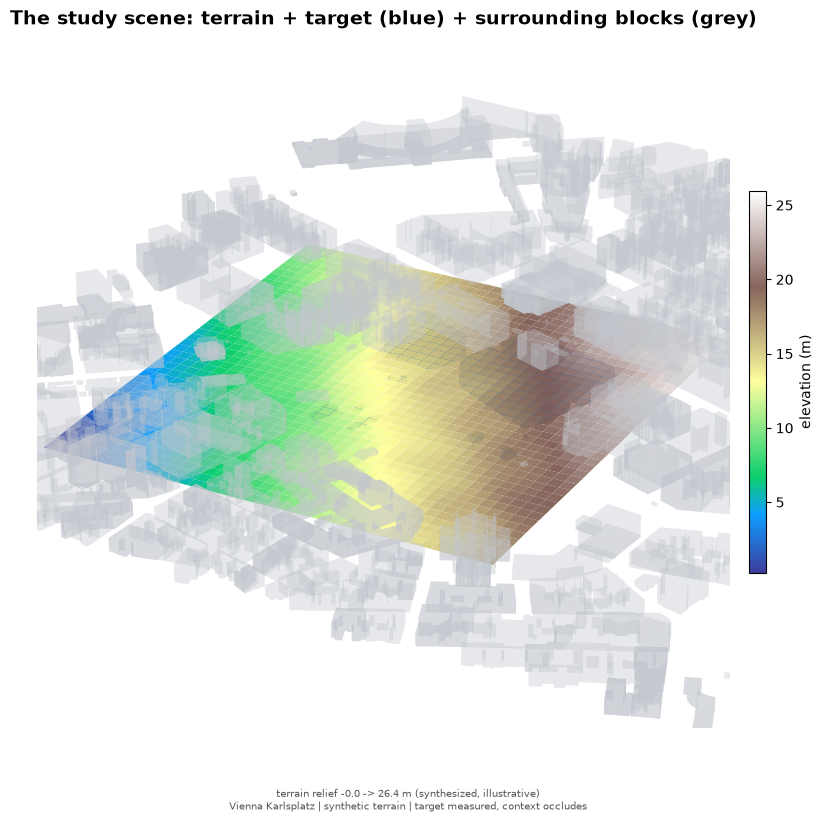

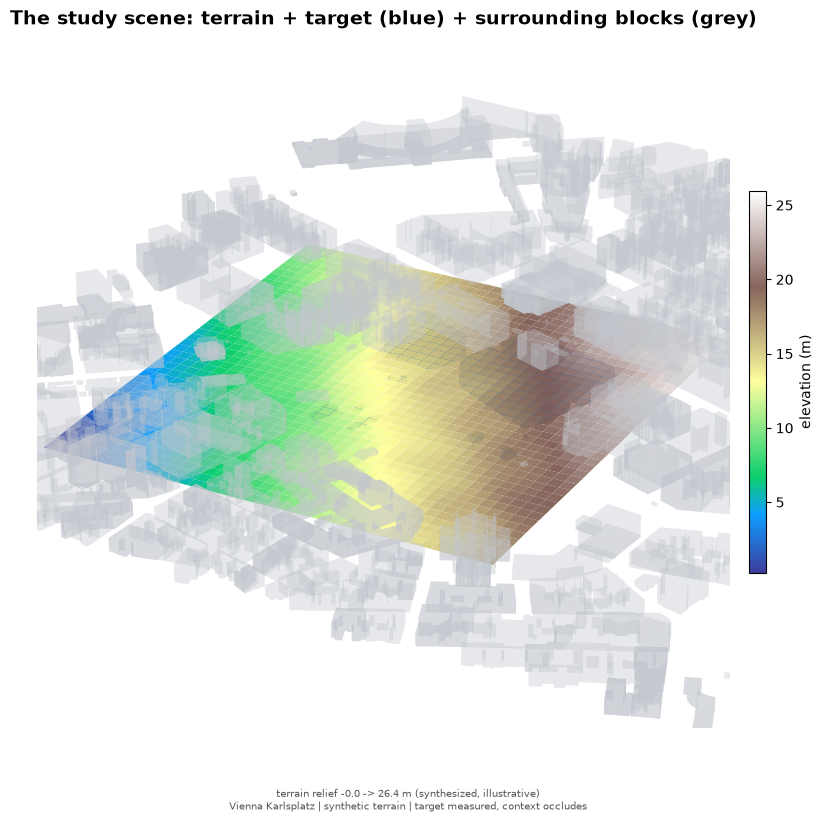

In [4]:
# The scene at a glance: terrain relief + the measured target buildings (solid
# blue) lifted out of the light translucent context blocks (grey occluders).
# Splitting target vs context keeps a busy urban scene readable.
fig, ax = ir.terrain_3d(
    heights,
    size_m=512.0,
    context_faces=ia.building_faces(context, max_buildings=600),
    target_faces=ia.building_faces(target),
    title="The study scene: terrain + target (blue) + surrounding blocks (grey)",
    note="Vienna Karlsplatz | synthetic terrain | target measured, context occludes",
)
fig

## Solar radiation - the full advanced payload

Target facades + context occluders + terrain drape + multi-month window, all
in one request. This is the headline urban-design run.

In [5]:
from infrared_sdk.analyses.types import (
    SolarRadiationModelRequest,
    BaseAnalysisPayload,
    AnalysesName,
)

# Summer multi-month window (Jun-Aug).
tp = TimePeriod(
    start_month=6, start_day=1, start_hour=5, end_month=8, end_day=31, end_hour=20
)
loc = Location(latitude=ia.VIENNA_LAT, longitude=ia.VIENNA_LON)
wp = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)
print("weather points (multi-month):", len(wp))

sr = SolarRadiationModelRequest.from_weatherfile_payload(
    BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation), loc, tp, wp
).to_dict()
sr["latitude"] = ia.VIENNA_LAT
sr["longitude"] = ia.VIENNA_LON
sr["geometries"] = target  # measure the target facades
sr["analysis-surfaces"] = "facades"
sr["surface-grid-size"] = 4.0
sr["surface-offset"] = 0.1
sr["partial-cells"] = True  # clip boundary cells
sr["min-coverage"] = 0.25
sr["context-geometry"] = context  # surrounding-block shadows
sr["ground-geometry"] = terrain_mesh  # terrain drape / occluder

sr_res, info = ia.run_job("solar-radiation", sr, label="combined", max_wait=500)
print(
    "frames:",
    len(sr_res["surfaces"]),
    "| sensors:",
    sr_res["sensor-count"],
    "| elapsed:",
    info["elapsed_s"],
    "s",
)

weather points (multi-month): 1472


[solar-radiation/combined] Succeeded in 0.5s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=7237
frames: 457 | sensors: 7237 | elapsed: 0.5 s


### Result payload, described

The combined run returns the standard **surface** payload (notebook `01`):
`surfaces` (per-frame `{origin, u-axis, v-axis, grid-size, nu, nv, values,
cell-area, cell-tris, area, mean, peak}`), per-building `aggregates`, and
`sensor-count` - for the **target** facades only. Context and terrain shape the
values (via shadowing / drape) but never appear in the output. Reconstruct the
world cells exactly as before (`reconstruct_cells`).

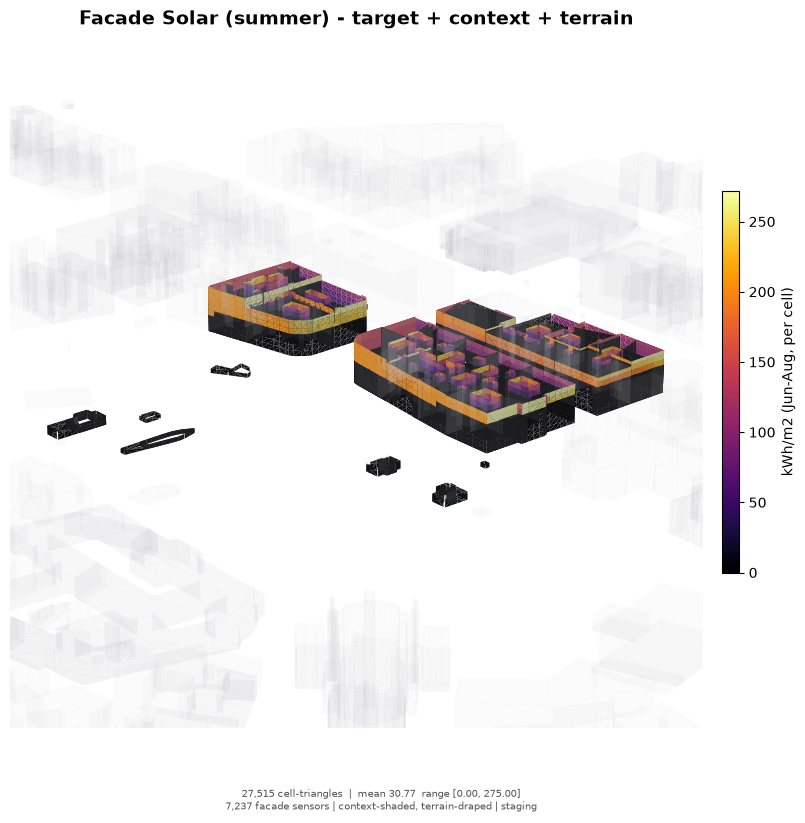

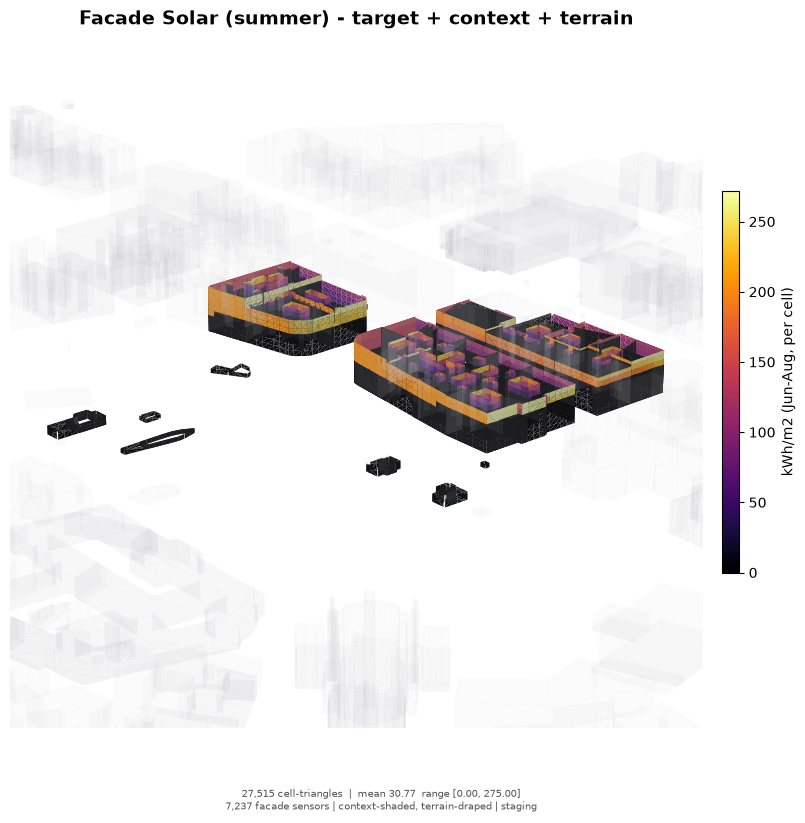

In [6]:
tris, values, normals = ia.reconstruct_cells(sr_res["surfaces"])
# Show the measured target massing plus a faint hint of the surrounding context.
fig, ax = ir.surface_mesh(
    tris,
    values,
    normals=normals,
    context_faces=ia.building_faces(target)
    + ia.building_faces(context, max_buildings=400),
    context_alpha=0.04,
    zmax=45,
    title="Facade Solar (summer) - target + context + terrain",
    cbar_label="kWh/m2 (Jun-Aug, per cell)",
    cmap="inferno",
    note=f"{sr_res['sensor-count']:,} facade sensors | context-shaded, terrain-draped | staging",
)
fig

## UTCI - advanced physics over terrain

Thermal comfort for the same site: `physics:"advanced"` (hourly stepping +
canopy ray-march) with vegetation, ground materials and the **terrain**
(`ground-geometry` is accepted on thermal models). Output is the standard
512x512 grid of felt temperature.

> `context-geometry` on advanced UTCI just merged (PR #119) but is not live
> until the next staging re-deploy, so we leave it off here and let the terrain
> + canopy do the work. For context occlusion on a thermal run today, use
> `physics:"v1"`.

In [7]:
from infrared_sdk.analyses.types import UtciModelRequest

utci = UtciModelRequest.from_weatherfile_payload(
    UtciModelRequest(
        analysis_type=AnalysesName.thermal_comfort_index,
        latitude=ia.VIENNA_LAT,
        longitude=ia.VIENNA_LON,
        time_period=tp,
    ),
    loc,
    tp,
    wp,
).to_dict()
utci["latitude"] = ia.VIENNA_LAT
utci["longitude"] = ia.VIENNA_LON
utci["geometries"] = target
if vegetation:
    utci["vegetation"] = vegetation
if ground:
    utci["ground-materials"] = ground
utci["ground-geometry"] = terrain_mesh
utci["physics"] = "advanced"
utci["canopy-transmissivity"] = 0.40

utci_res, info = ia.run_job(
    "thermal-comfort-index", utci, label="advanced+terrain", max_wait=500
)
grid = np.array(utci_res["output"], dtype=float)
print(
    "UTCI grid:",
    grid.shape,
    "| mean %.2f degC" % float(np.nanmean(grid)),
    "| elapsed:",
    info["elapsed_s"],
    "s",
)

[thermal-comfort-index/advanced+terrain] Succeeded in 5.7s  keys=['max-legend', 'min-legend', 'output']
UTCI grid: (512, 512) | mean 25.40 degC | elapsed: 5.7 s


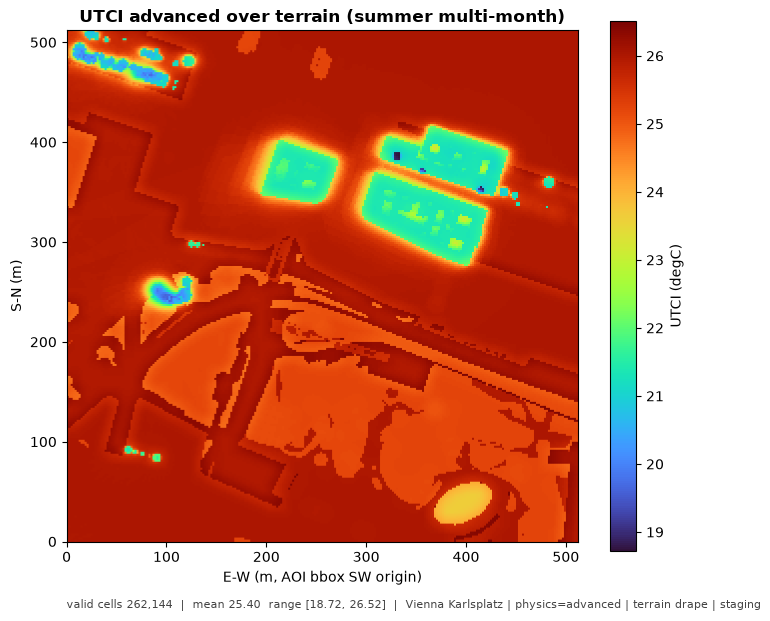

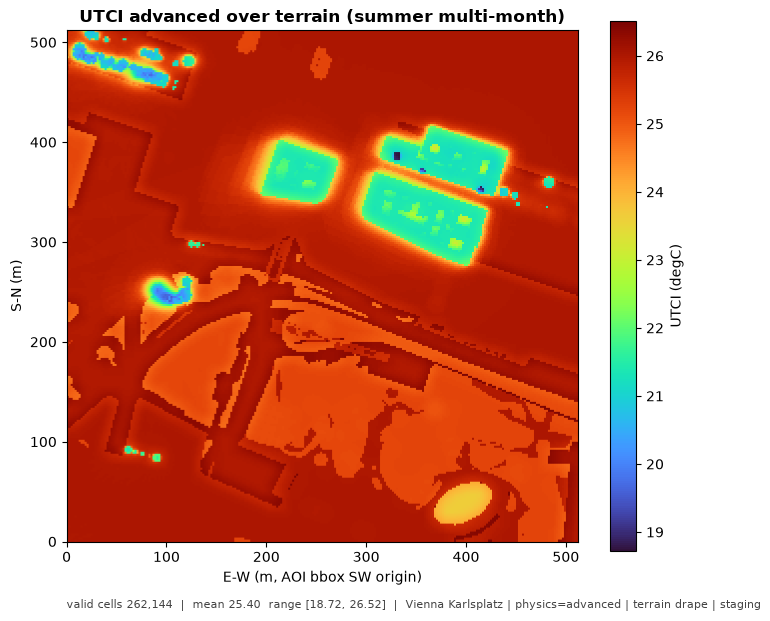

In [8]:
fig, ax = ir.grid_heatmap(
    grid,
    title="UTCI advanced over terrain (summer multi-month)",
    cbar_label="UTCI (degC)",
    cmap="turbo",
    crop=True,
    note="Vienna Karlsplatz | physics=advanced | terrain drape | staging",
)
fig

## Summary - the advanced toolkit, combined

| Ingredient | Field | Notebook |
|---|---|---|
| facade sensors | `analysis-surfaces:"facades"` + `partial-cells` | `01` |
| surrounding shadows | `context-geometry` | `07` |
| terrain | `ground-geometry` | `06` |
| seasonal window | multi-month `time-period` | `03` |
| advanced thermal | `physics:"advanced"` + `canopy-transmissivity` | `05` |

All of it is direct-API today (the SDK's typed models don't expose these
fields yet), POSTed to the same async endpoints the SDK uses. Swap the
synthetic terrain for a real DEM and the larger fetch for your own site, and
this is a production microclimate study.